In [17]:
"""
Phase 5 — Regime Definition

Objective
---------
Identify whether housing affordability (DTI) exhibits a regime threshold
beyond which downside housing risk increases materially.

This phase focuses on regime identification, not portfolio optimization.

Key question:
Does downside risk rise gradually with DTI,
or does it behave more like a switch once DTI crosses a critical level?
"""

'\nPhase 5 — Regime Definition\n\nObjective\n---------\nIdentify whether housing affordability (DTI) exhibits a regime threshold\nbeyond which downside housing risk increases materially.\n\nThis phase focuses on regime identification, not portfolio optimization.\n\nKey question:\nDoes downside risk rise gradually with DTI,\nor does it behave more like a switch once DTI crosses a critical level?\n'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("../../data/processed/phase5_master_mock.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,dti,real_rate,regime,real_price_index,ret_fwd_1q,permits,supply_high
0,2013-01-01,3.324179,0.010687,stable,100.000000,0.017905,101.299414,0
1,2013-04-01,3.284583,0.007747,stable,101.806634,0.017563,106.443086,0
2,2013-07-01,3.600220,0.013174,stable,103.610510,0.013861,98.768910,0
3,2013-10-01,3.938204,0.012967,stable,105.056646,0.010309,100.547669,0
4,2014-01-01,3.618057,0.013533,stable,106.145229,-0.003221,111.633493,1


In [4]:
df.columns

Index(['date', 'dti', 'real_rate', 'regime', 'real_price_index', 'ret_fwd_1q',
       'permits', 'supply_high'],
      dtype='str')

In [5]:
cols = [
    "date",
    "dti",
    "ret_fwd_1q"
]

df5 = df[cols].dropna().copy()
df5 = df5.sort_values("date").reset_index(drop=True)

df5["loss"] = -df5["ret_fwd_1q"]
df5["tail_event_2"] = (df5["ret_fwd_1q"] <= -0.02).astype(int)
df5["tail_event_3"] = (df5["ret_fwd_1q"] <= -0.03).astype(int)

df5.head()

,date,dti,ret_fwd_1q,loss,tail_event_2,tail_event_3
0,2013-01-01,3.324179,0.017905,-0.017905,0,0
1,2013-04-01,3.284583,0.017563,-0.017563,0,0
2,2013-07-01,3.600220,0.013861,-0.013861,0,0
3,2013-10-01,3.938204,0.010309,-0.010309,0,0
4,2014-01-01,3.618057,-0.003221,0.003221,0,0


In [6]:
df5.describe()

,date,dti,ret_fwd_1q,loss,tail_event_2,tail_event_3
count,48,48.000000,48.000000,48.000000,48.000000,48.000000
mean,2018-11-15 16:30:00,5.948676,0.001767,-0.001767,0.145833,0.041667
min,2013-01-01 00:00:00,3.284583,-0.043809,-0.039951,0.000000,0.000000
25%,2015-12-09 00:00:00,4.404537,-0.009694,-0.014329,0.000000,0.000000
50%,2018-11-16 00:00:00,5.936435,0.005861,-0.005861,0.000000,0.000000
75%,2021-10-24 00:00:00,7.366418,0.014329,0.009694,0.000000,0.000000
max,2024-10-01 00:00:00,9.064281,0.039951,0.043809,1.000000,1.000000
std,NaN,1.646680,0.018584,0.018584,0.356674,0.201941


In [7]:
df5["dti_q"] = pd.qcut(df5["dti"], 5, labels=False, duplicates="drop") + 1

grouped = df5.groupby("dti_q").agg(
    mean_ret=("ret_fwd_1q", "mean"),
    median_ret=("ret_fwd_1q", "median"),
    min_ret=("ret_fwd_1q", "min"),
    tail2_rate=("tail_event_2", "mean"),
    tail3_rate=("tail_event_3", "mean"),
)

grouped["p05_ret"] = df5.groupby("dti_q")["ret_fwd_1q"].quantile(0.05)

grouped

,mean_ret,median_ret,min_ret,tail2_rate,tail3_rate,p05_ret
dti_q,,,,,,
1,0.012546,0.011279,-0.003221,0.000000,0.0,-0.000457
2,0.009920,0.012016,-0.010899,0.000000,0.0,-0.003232
3,0.012873,0.015842,-0.012575,0.000000,0.0,-0.008858
4,-0.005604,-0.006787,-0.027602,0.111111,0.0,-0.024230
5,-0.020822,-0.022593,-0.043809,0.600000,0.2,-0.039775


In [8]:
dfs = df5.sort_values("dti").reset_index(drop=True)

window = max(8, len(dfs) // 10)

dfs["ret_roll"] = dfs["ret_fwd_1q"].rolling(window, center=True).mean()
dfs["tail_roll"] = dfs["tail_event_2"].rolling(window, center=True).mean()

dfs.head()

,date,dti,ret_fwd_1q,loss,tail_event_2,tail_event_3,dti_q,ret_roll,tail_roll
0,2013-04-01,3.284583,0.017563,-0.017563,0,0,1,NaN,NaN
1,2013-01-01,3.324179,0.017905,-0.017905,0,0,1,NaN,NaN
2,2013-07-01,3.600220,0.013861,-0.013861,0,0,1,NaN,NaN
3,2014-01-01,3.618057,-0.003221,0.003221,0,0,1,NaN,NaN
4,2014-04-01,3.737210,0.008478,-0.008478,0,0,1,0.009851,0.0


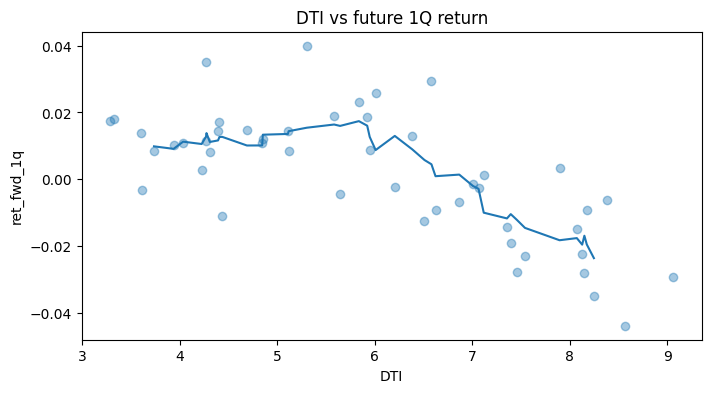

In [9]:
plt.figure(figsize=(8, 4))
plt.scatter(dfs["dti"], dfs["ret_fwd_1q"], alpha=0.4)
plt.plot(dfs["dti"], dfs["ret_roll"])
plt.title("DTI vs future 1Q return")
plt.xlabel("DTI")
plt.ylabel("ret_fwd_1q")
plt.show()

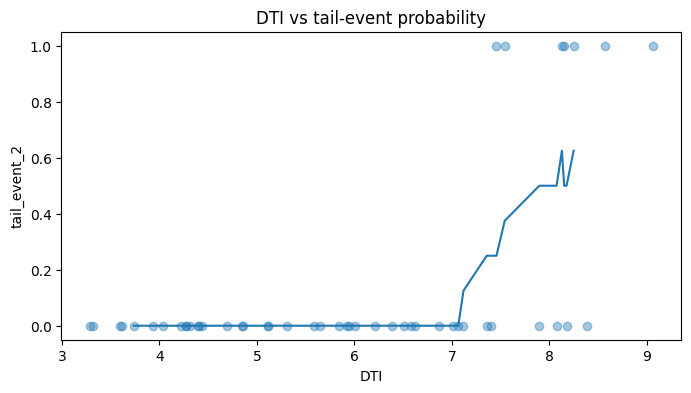

In [10]:
plt.figure(figsize=(8, 4))
plt.scatter(dfs["dti"], dfs["tail_event_2"], alpha=0.4)
plt.plot(dfs["dti"], dfs["tail_roll"])
plt.title("DTI vs tail-event probability")
plt.xlabel("DTI")
plt.ylabel("tail_event_2")
plt.show()

In [11]:
thresholds = np.linspace(df5["dti"].quantile(0.2), df5["dti"].quantile(0.8), 25)

rows = []

for c in thresholds:
    temp = df5.copy()
    temp["fragile"] = (temp["dti"] >= c).astype(int)

    g0 = temp.loc[temp["fragile"] == 0, "ret_fwd_1q"]
    g1 = temp.loc[temp["fragile"] == 1, "ret_fwd_1q"]

    rows.append({
        "threshold": c,
        "share_fragile": temp["fragile"].mean(),
        "mean_nonfragile": g0.mean(),
        "mean_fragile": g1.mean(),
        "p05_nonfragile": g0.quantile(0.05),
        "p05_fragile": g1.quantile(0.05),
        "tail2_nonfragile": temp.loc[temp["fragile"] == 0, "tail_event_2"].mean(),
        "tail2_fragile": temp.loc[temp["fragile"] == 1, "tail_event_2"].mean(),
    })

thresh_tbl = pd.DataFrame(rows)
thresh_tbl.head()

,threshold,share_fragile,mean_nonfragile,mean_fragile,p05_nonfragile,p05_fragile,tail2_nonfragile,tail2_fragile
0,4.289260,0.791667,0.012546,-0.001070,-0.000457,-0.030118,0.0,0.184211
1,4.423358,0.729167,0.012697,-0.002293,0.000464,-0.030952,0.0,0.200000
2,4.557457,0.708333,0.011012,-0.002040,-0.005908,-0.031230,0.0,0.205882
3,4.691556,0.687500,0.011258,-0.002548,-0.005524,-0.031508,0.0,0.212121
4,4.825654,0.687500,0.011258,-0.002548,-0.005524,-0.031508,0.0,0.212121


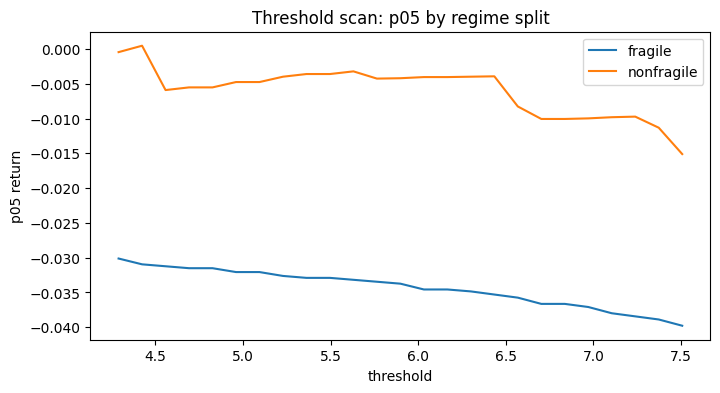

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(thresh_tbl["threshold"], thresh_tbl["p05_fragile"], label="fragile")
plt.plot(thresh_tbl["threshold"], thresh_tbl["p05_nonfragile"], label="nonfragile")
plt.title("Threshold scan: p05 by regime split")
plt.xlabel("threshold")
plt.ylabel("p05 return")
plt.legend()
plt.show()

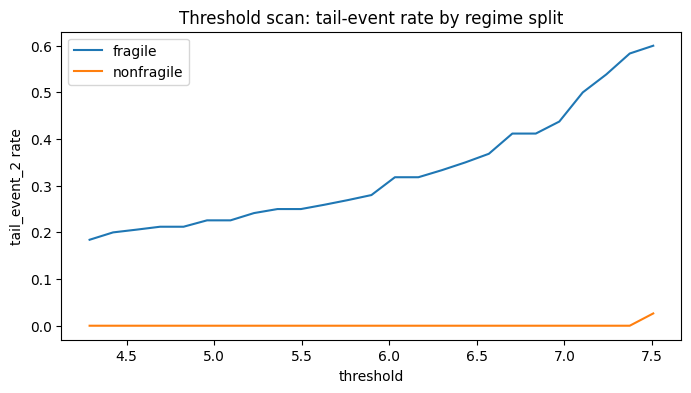

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(thresh_tbl["threshold"], thresh_tbl["tail2_fragile"], label="fragile")
plt.plot(thresh_tbl["threshold"], thresh_tbl["tail2_nonfragile"], label="nonfragile")
plt.title("Threshold scan: tail-event rate by regime split")
plt.xlabel("threshold")
plt.ylabel("tail_event_2 rate")
plt.legend()
plt.show()

In [14]:
thresh_tbl.sort_values("tail2_fragile", ascending=False).head(10)

,threshold,share_fragile,mean_nonfragile,mean_fragile,p05_nonfragile,p05_fragile,tail2_nonfragile,tail2_fragile
24,7.507627,0.208333,0.007711,-0.020822,-0.015107,-0.039775,0.026316,0.600000
23,7.373528,0.250000,0.009439,-0.021249,-0.011318,-0.038879,0.000000,0.583333
22,7.239429,0.270833,0.010120,-0.020722,-0.009726,-0.038430,0.000000,0.538462
21,7.105331,0.291667,0.010375,-0.019140,-0.009810,-0.037982,0.000000,0.500000
20,6.971232,0.333333,0.011156,-0.017011,-0.009977,-0.037085,0.000000,0.437500
19,6.837133,0.354167,0.011735,-0.016410,-0.010061,-0.036637,0.000000,0.411765
18,6.703035,0.354167,0.011735,-0.016410,-0.010061,-0.036637,0.000000,0.411765
17,6.568936,0.395833,0.011844,-0.013614,-0.008266,-0.035741,0.000000,0.368421
16,6.434838,0.416667,0.012716,-0.013562,-0.003932,-0.035292,0.000000,0.350000
15,6.300739,0.437500,0.012704,-0.012295,-0.003987,-0.034844,0.000000,0.333333


In [15]:
X = sm.add_constant(df5["dti"])
y = df5["tail_event_2"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.192254
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           tail_event_2   No. Observations:                   48
Model:                          Logit   Df Residuals:                       46
Method:                           MLE   Df Model:                            1
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.5372
Time:                        17:13:25   Log-Likelihood:                -9.2282
converged:                       True   LL-Null:                       -19.940
Covariance Type:            nonrobust   LLR p-value:                 3.683e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -19.8078      7.854     -2.522      0.012     -35.202      -4.413
dti            2.4698      0.

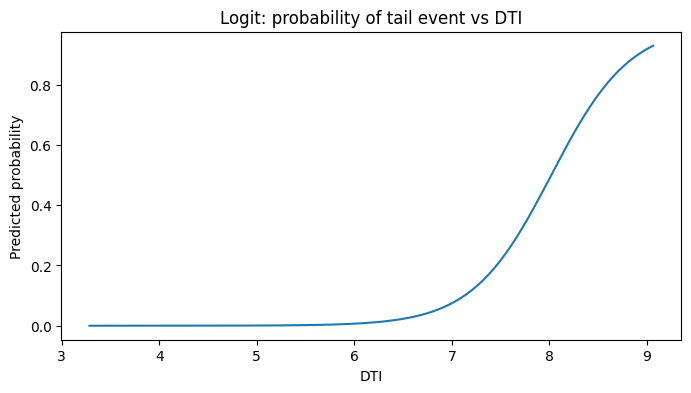

In [16]:
x_grid = np.linspace(df5["dti"].min(), df5["dti"].max(), 200)
Xg = sm.add_constant(pd.DataFrame({"dti": x_grid}))
p_hat = model.predict(Xg)

plt.figure(figsize=(8, 4))
plt.plot(x_grid, p_hat)
plt.title("Logit: probability of tail event vs DTI")
plt.xlabel("DTI")
plt.ylabel("Predicted probability")
plt.show()

In [18]:
regime_threshold = 7.2

df["affordability_regime"] = (df["dti"] >= regime_threshold).astype(int)

df[["dti","affordability_regime"]].head()

,dti,affordability_regime
0,3.324179,0
1,3.284583,0
2,3.600220,0
3,3.938204,0
4,3.618057,0


In [19]:
df.groupby("affordability_regime")["ret_fwd_1q"].describe()

,count,mean,std,min,25%,50%,75%,max
affordability_regime,,,,,,,,
0,35.0,0.010120,0.012486,-0.012575,-0.000056,0.010993,0.017298,0.039951
1,13.0,-0.020722,0.012635,-0.043809,-0.028107,-0.022256,-0.014389,0.003455


In [20]:
df.groupby("affordability_regime")["ret_fwd_1q"].quantile([0.05,0.1])

affordability_regime      
0                     0.05   -0.009726
                      0.10   -0.005798
1                     0.05   -0.038430
                      0.10   -0.033732
Name: ret_fwd_1q, dtype: float64

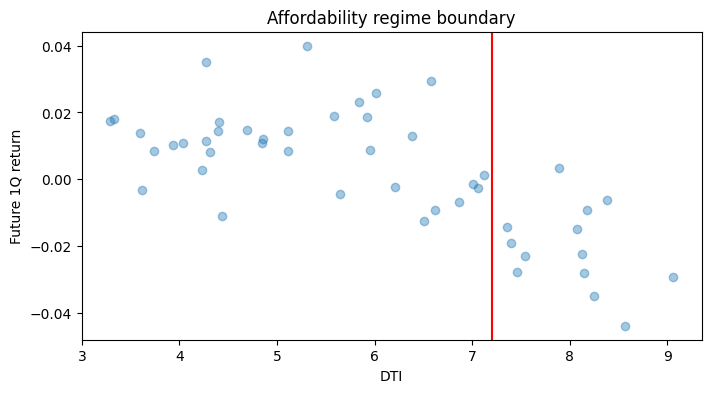

In [21]:
plt.figure(figsize=(8,4))

plt.scatter(df["dti"], df["ret_fwd_1q"], alpha=0.4)

plt.axvline(regime_threshold, color="red")

plt.title("Affordability regime boundary")
plt.xlabel("DTI")
plt.ylabel("Future 1Q return")

plt.show()

Evidence suggests that housing affordability risk behaves as a regime switch rather than a linear deterioration.

Across multiple diagnostics, the transition into a fragile affordability regime occurs when DTI rises above ~7.

In this regime:
• mean forward returns turn negative
• downside tail risk increases materially